## ------------------------------------------------------------ ###
## Set up environment
## ------------------------------------------------------------ ###

In [12]:
import numpy as np
import pandas as pd
import cftime
import re
import time
import gc
import os
import sys
import math
import glob
import datetime
from scipy.ndimage import label, generate_binary_structure

from functions import *
from functions_stage2 import (get_rainfall_cube_subsection, find_max_precip_location_new, 
                        find_temporal_profile_new, maybe_diagnose, analyse_peak_event,
                             plot_cluster_check,get_rainfall_lookback_cube)
verbose=True

# ── Config ────────────────────────────────────────────────────────────────────
from config import RAINFALL_CSV_DIR, CATCHMENT_LOOKUP_DICT, OUT_DIR, CATCHMENTS, ENSEMBLE_MEMBERS 

## ------------------------------------------------------------ ###
## Loop through catchments processing
## ------------------------------------------------------------ ###

105 InnerHebrides 11
372
EM11: 372 events to process


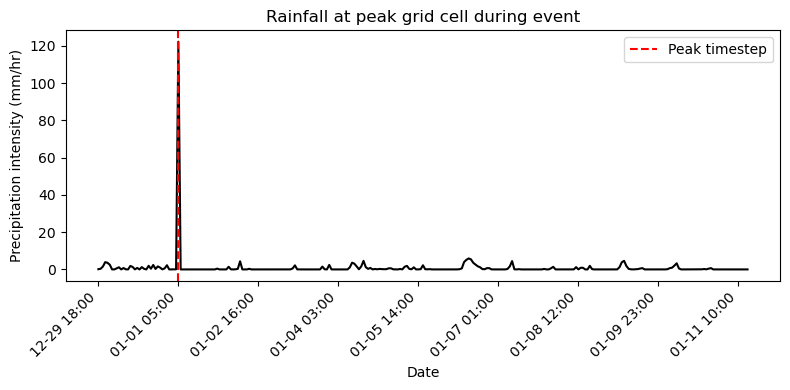

In [13]:
catchment_num = '105'
event_num = 259
ens_num = '11'

catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
print(catchment_num, catchment_name, ens_num)

# print(f"Starting: {catchment_name}")
boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

begin_time = time.time()
full_rain_cube = get_rainfall_cube_subsection(2015, '01', f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/", 1, 2)
FULL_MASK_2D   = mask_cube_with_catchment_full_grid(full_rain_cube[0], CATCHMENT_POLY, method='center_point')
year_cube, mask_x_offset, mask_y_offset = subset_cube_to_bbox(full_rain_cube, CATCHMENT_POLY, buffer=0)
ny_sub = year_cube.shape[1]
nx_sub = year_cube.shape[2]
mask_2d_sub = FULL_MASK_2D[mask_y_offset:mask_y_offset + ny_sub, 
                            mask_x_offset:mask_x_offset + nx_sub]
# print(f"Mask created in {time.time()-begin_time:.1f}s")
del full_rain_cube, year_cube

flood_dir    = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/"

fp = os.path.join(OUT_DIR,f"Catchment_{catchment_num}",f"{catchment_name}_EM{ens_num}_new.pkl")

results_this_ens = []

rainfall_events  = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
print(len(rainfall_events))
rainfall_events['event_num']  = range(1, len(rainfall_events) + 1)
rainfall_events['hydro_year'] = rainfall_events['start_year'].where(rainfall_events['start_month'] != 12,
        rainfall_events['start_year'] + 1)
# print(f"rainfall events is length: {len(rainfall_events)}")

rainfall_cube_dir = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
print(f"EM{ens_num}: {len(rainfall_events)} events to process")

event_details_cache = {
    ev: get_rainfall_event_details(rainfall_events, ev)
    for ev in rainfall_events['event_num']}

the_event = rainfall_events[rainfall_events['event_num']==event_num]               

for row in the_event.itertuples():
    pass
    
event_details = event_details_cache[event_num]
year = row.hydro_year

year_cube = get_rainfall_cube_subsection(year, ens_num, rainfall_cube_dir, 
                                     event_details['start_idx']-1, event_details['stop_idx'])
year_cube.data = np.where(FULL_MASK_2D, year_cube.data, np.nan)
year_cube, x_offset, y_offset = subset_cube_to_bbox(year_cube, CATCHMENT_POLY, buffer=0)
time_coord  = year_cube.coord('time')

t0 = time_coord.units.num2date(np.floor(time_coord.points[0]))
t_end = time_coord.units.num2date(time_coord.points[-1])
event_start = cftime.Datetime360Day(event_details['start_year'], 
                             event_details['start_month'], 
                             event_details['start_day'], 
                             event_details['start_hour'])
event_start_within_cube = t0 <= event_start <= t_end

this_event_results = find_max_precip_location_new(
    year_cube, event_details['start_idx'], event_details['stop_idx'],
    x_offset=x_offset, y_offset=y_offset, mask_2d=mask_2d_sub)

this_event_results['ens']       = ens_num
this_event_results['start_idx'] = event_details['start_idx']
this_event_results['stop_idx']  = event_details['stop_idx']
this_event_results['max_precip_from_csv']  = event_details['max_precip_from_csv']
this_event_results['start_year']  = event_details['start_year']
this_event_results['start_month']  = event_details['start_month']
this_event_results['start_day']  = event_details['start_day']
this_event_results['start_hour']  = event_details['start_hour']
this_event_results['event_num']  = event_details['event_num']
this_event_results['event_durations']  = event_details['event_durations']
if not event_start_within_cube:
    this_event_results['time_mismatch'] = True
    print("TIME MISMACH")
else:
    this_event_results['time_mismatch'] = False

                            
t = time_coord.units.num2date(time_coord.points[this_event_results['t_local']])
this_event_results['rainfall_peak_day'] = cftime.Datetime360Day(t.year, t.month, t.day)
this_event_results['hydro_day_360'] = (
    (this_event_results['rainfall_peak_day'].month % 12) * 30
    + this_event_results['rainfall_peak_day'].day)
this_event_results['day_360'] = (
    (this_event_results['rainfall_peak_day'].month - 1) * 30
    + this_event_results['rainfall_peak_day'].day)
this_event_results['t_local_rebased']    = this_event_results['t_global'] - this_event_results['start_idx']

rainfall_at_peak  = get_data_at_peak_cell(year_cube, this_event_results, 'x_idx', 'y_idx')
temp_profile_dict = find_temporal_profile_new(rainfall_at_peak, this_event_results, plot=True)
